### Evaluación N°1


### 1. Portada
* Proyecto: Clasificación de Escenas Naturales con Perceptrón Multicapa (MLP)
* Integrantes: Diego Muñoz, Paula Leiva, Sofía Paillalef
* Asignatura: Técnicas Avanzadas de Machine Learning I
* Fecha: 10.09.26

## 2. Contexto E Importancia
El trabajo consiste en implementar un modelo de red neuronal tipo MLP para resolver un problema de clasificación utilizando
uno de los datasets propuestos. El objetivo no será solamente obtener una métrica alta, sino comprender el flujo completo de trabajo en
aprendizaje supervisado: carga de datos, preprocesamiento, definición de clases, entrenamiento, validación y análisis de resultados.

### 3.SELECCIÓN Y DESCRIPCIÓN DEL DATASET

* Intel Image Classification Dataset
* Problema: Clasificación de escenarios naturales.
* Características:
* ~25.000 imágenes
* 150×150 px
* 6 clases
* https://www.kaggle.com/datasets/puneet6060/intel-image-classification


In [ ]:
import os #sistema operativo, manejo de archivos y similares
import zipfile # importar archivo zip
import numpy as np #calculos
import matplotlib.pyplot as plt #graficos
import seaborn as sns #graficos
import tensorflow as tf #crear y entrenar una red neuronal
from tensorflow.keras import layers, models #ayuda de componenetes para tensorflow
from sklearn.metrics import classification_report, confusion_matrix #herramientas para evaluar el modelo

In [ ]:

#3.1 DEFINICION INICIAL, CARGA DEL ZIP Y RUTAS
SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

clases_originales = ['forest', 'glacier', 'mountain']
clases_esp = ['Bosque', 'Glaciar', 'Montaña']
rutas_zip = 'Intel Image Classification.zip'

if os.path.exists(rutas_zip):
    with zipfile.ZipFile(rutas_zip, 'r') as referencia_zip:
        referencia_zip.extractall('.')
    print("¡zip descomprimido correctamente!")

def buscar_carpeta_exacta(carpeta_objetivo):
    for raiz, carpetas, _ in os.walk('.'):
        if carpeta_objetivo in carpetas:
            return os.path.abspath(os.path.join(raiz, carpeta_objetivo))
    return None

def ajustar_ruta(ruta_base, lista_clases):
    if ruta_base is None: return None
    ruta_anidada = os.path.join(ruta_base, os.path.basename(ruta_base))
    if os.path.isdir(ruta_anidada) and all(os.path.isdir(os.path.join(ruta_anidada, c)) for c in lista_clases):
        return ruta_anidada
    return ruta_base

def ajustar_pred(ruta_base):
    if ruta_base is None: return None
    ruta_anidada = os.path.join(ruta_base, os.path.basename(ruta_base))
    if os.path.isdir(ruta_anidada) and len(os.listdir(ruta_anidada)) > 0:
        return ruta_anidada
    return ruta_base

ruta_base_entrenamiento = buscar_carpeta_exacta('seg_train')
ruta_base_prueba = buscar_carpeta_exacta('seg_test')
ruta_base_prediccion = buscar_carpeta_exacta('seg_pred')

dir_entrenamiento = ajustar_ruta(ruta_base_entrenamiento, clases_originales)
dir_prueba = ajustar_ruta(ruta_base_prueba, clases_originales)
dir_prediccion = ajustar_pred(ruta_base_prediccion)


¡zip descomprimido correctamente!


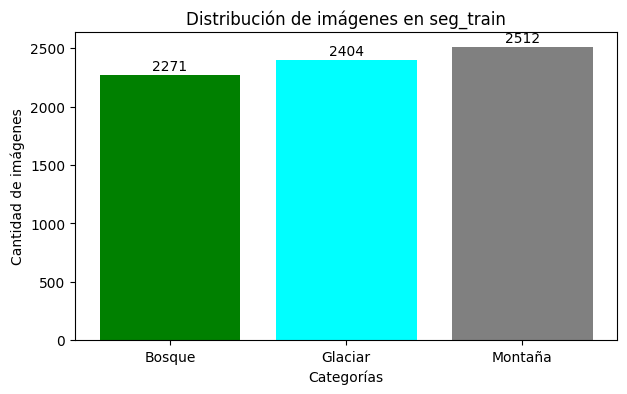

In [ ]:

# 4. ANÁLISIS EXPLORATORIO DE IMAGENES

conteos = {}
for clase_orig, clase_esp in zip(clases_originales, clases_esp):
    ruta_clase = os.path.join(dir_entrenamiento, clase_orig) if dir_entrenamiento else ""
    if os.path.exists(ruta_clase):
        conteos[clase_esp] = len([f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    else:
        conteos[clase_esp] = 0

plt.figure(figsize=(7, 4))
barras = plt.bar(conteos.keys(), conteos.values(), color=['green', 'cyan', 'gray'])
plt.title('Distribución de imágenes en seg_train')
plt.ylabel('Cantidad de imágenes')
plt.xlabel('Categorías')

for barra in barras:
    valor_y = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, valor_y + 10, int(valor_y), ha='center', va='bottom')

plt.show()

In [ ]:

# 5. PREPROCESAMIENTO Y CARGA DE DATOS

t_imagen = (64, 64)
t_lote = 32

# CARGA
entrenamiento = tf.keras.preprocessing.image_dataset_from_directory(
    dir_entrenamiento,
    labels='inferred',
    label_mode='int',
    class_names=clases_originales,
    validation_split=0.2,
    subset="training",
    seed=SEMILLA,
    image_size=t_imagen,
    batch_size=t_lote
)

validacion = tf.keras.preprocessing.image_dataset_from_directory(
    dir_entrenamiento,
    labels='inferred',
    label_mode='int',
    class_names=clases_originales,
    validation_split=0.2,
    subset="validation",
    seed=SEMILLA,
    image_size=t_imagen,
    batch_size=t_lote
)

# NORMALIZACION DE PIXELES
capa_normalizacion = layers.Rescaling(1./255)
entrenamiento = entrenamiento.map(lambda x, y: (capa_normalizacion(x), y))
validacion = validacion.map(lambda x, y: (capa_normalizacion(x), y))

Found 7187 files belonging to 3 classes.
Using 5750 files for training.
Found 7187 files belonging to 3 classes.
Using 1437 files for validation.


In [ ]:

# 6. IMPLEMENTACIÓN DEL MLP

modelo = models.Sequential([

    layers.Flatten(input_shape=(64, 64, 3)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])


modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,267 (12.13 MB)

 Trainable params: 3,179,267 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.6550 - loss: 1.2908 - val_accuracy: 0.7738 - val_loss: 0.5597
Epoch 2/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.7595 - loss: 0.5845 - val_accuracy: 0.7578 - val_loss: 0.5892
Epoch 3/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7687 - loss: 0.5724 - val_accuracy: 0.6945 - val_loss: 0.7120
Epoch 4/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.7843 - loss: 0.5414 - val_accuracy: 0.8051 - val_loss: 0.5068
Epoch 5/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.7960 - loss: 0.5026 - val_accuracy: 0.7766 - val_loss: 0.5506
Epoch 6/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.8125 - loss: 0.4784 - val_accuracy: 0.7648 - val_loss: 0.5918
Epoch 7/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.8132 - loss: 0.4623 - val_accuracy: 0.8031 - val_loss: 0.4998
Epoch 8/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8157 - loss: 0.4596 - va

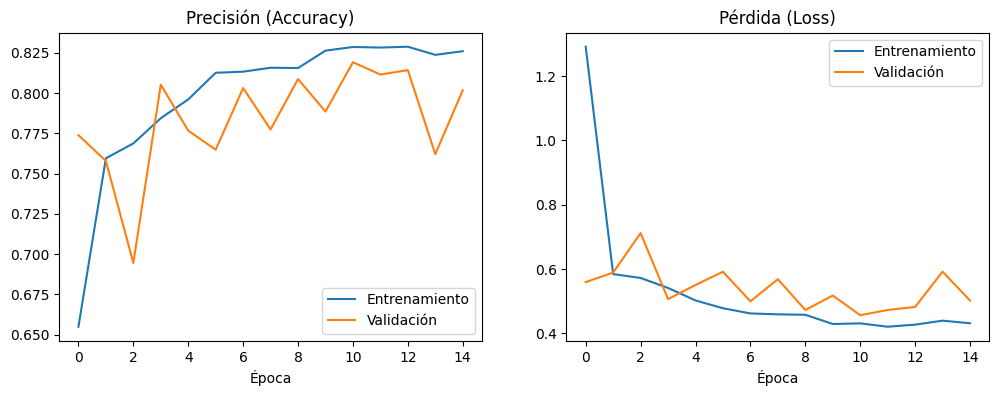

In [ ]:

# 7. ENTRENAMIENTO Y VALIDACIÓN

epocas = 15
historial = modelo.fit(
    entrenamiento,
    validation_data=validacion,
    epochs=epocas
)


#GRAFICO DE VISUALIZACION
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()
plt.show()

Found 1552 files belonging to 3 classes.

--- REPORTE DE CLASIFICACIÓN EN SEG_TEST ---
              precision    recall  f1-score   support

      Bosque       0.95      0.81      0.87       474
     Glaciar       0.74      0.77      0.76       553
     Montaña       0.72      0.78      0.75       525

    accuracy                           0.78      1552
   macro avg       0.80      0.79      0.79      1552
weighted avg       0.80      0.78      0.79      1552



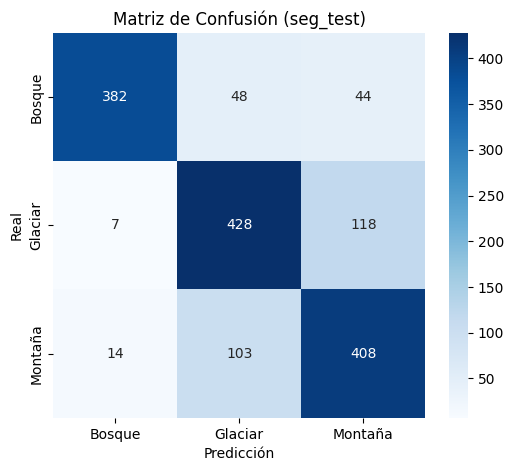

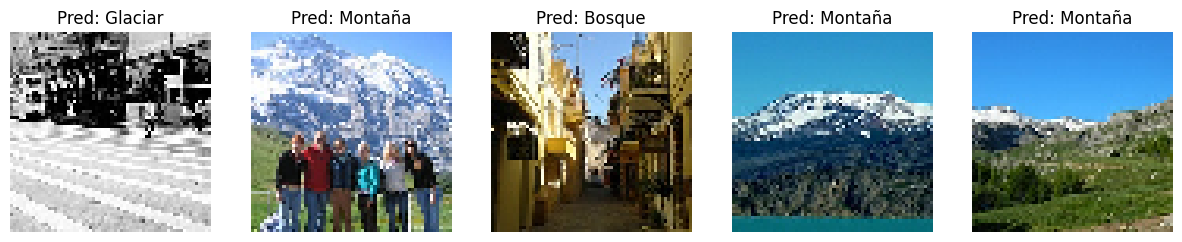

In [ ]:

# 8. RESULTADOS Y ANÁLISIS DE ERRORES

prueba = tf.keras.preprocessing.image_dataset_from_directory(
    dir_prueba,
    labels='inferred',
    label_mode='int',
    class_names=clases_originales,
    image_size=t_imagen,
    batch_size=t_lote,
    shuffle=False
)
prueba = prueba.map(lambda x, y: (capa_normalizacion(x), y))

y_reales = []
y_predichos = []

for imagenes, etiquetas in prueba:
    predicciones = modelo.predict(imagenes, verbose=0)
    y_reales.extend(etiquetas.numpy())
    y_predichos.extend(np.argmax(predicciones, axis=1))

print("\n--- REPORTE DE CLASIFICACIÓN EN SEG_TEST ---")
print(classification_report(y_reales, y_predichos, target_names=clases_esp))

# MATRIZ DE CONFUSION
matriz_confusion = confusion_matrix(y_reales, y_predichos)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=clases_esp, yticklabels=clases_esp)
plt.title('Matriz de Confusión (seg_test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# PREDICCIONES EN SEG_PRED
if dir_prediccion and os.path.exists(dir_prediccion):
    archivos_prediccion = [os.path.join(dir_prediccion, f) for f in os.listdir(dir_prediccion) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    if archivos_prediccion:
        plt.figure(figsize=(15, 3))
        for i, ruta_imagen in enumerate(archivos_prediccion):
            imagen = tf.keras.utils.load_img(ruta_imagen, target_size=t_imagen)
            arreglo_imagen = tf.keras.utils.img_to_array(imagen) / 255.0
            lote_imagen = np.expand_dims(arreglo_imagen, axis=0)

            prediccion = modelo.predict(lote_imagen, verbose=0)
            clase_predicha_es = clases_esp[np.argmax(prediccion)]

            plt.subplot(1, 5, i+1)
            plt.imshow(imagen)
            plt.title(f"Pred: {clase_predicha_es}")
            plt.axis('off')
        plt.show()